In [1]:
# ==============================================
# BLOCK 1 — Imports
# ==============================================

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc

import time
import io

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# ==============================================
# BLOCK 1.5 — Output Directories
# ==============================================

BASE_DIR = Path.cwd().parent

RESULTS_DIR = (
    BASE_DIR /
    "results" /
    "compression_effects"
)

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")

Results directory: /home/megh/arrow-ipc-analysis-linux/results/compression_effects


In [3]:
# ==============================================
# BLOCK 2 — Experiment Configuration
# ==============================================

print("\n" + "="*80)
print("ARROW IPC COMPRESSION EFFECTS EXPERIMENT")
print("="*80)

N_ROWS = 1_000_000

print(f"Rows: {N_ROWS:,}")


ARROW IPC COMPRESSION EFFECTS EXPERIMENT
Rows: 1,000,000


In [4]:
# ==============================================
# BLOCK 3 — Create Synthetic Dataset
# ==============================================

print("\n" + "="*80)
print("CREATING DATASET")
print("="*80)

np.random.seed(42)

df = pd.DataFrame({
    "feature_1": np.random.randn(N_ROWS),
    "feature_2": np.random.randn(N_ROWS),
    "feature_3": np.random.randint(
        0,
        1000,
        N_ROWS
    ),
    "feature_4": np.random.rand(N_ROWS),
    "category": np.random.choice(
        ["A", "B", "C", "D"],
        N_ROWS
    ),
    "text": [
        "sample_text_" + str(i % 100)
        for i in range(N_ROWS)
    ]
})

print(df.head())
print(f"\nDataset shape: {df.shape}")


CREATING DATASET
   feature_1  feature_2  feature_3  feature_4 category           text
0   0.496714   0.169172        639   0.486056        D  sample_text_0
1  -0.138264  -0.121505        585   0.649509        D  sample_text_1
2   0.647689   1.156625        445   0.377894        B  sample_text_2
3   1.523030   0.200086        732   0.355518        B  sample_text_3
4  -0.234153   0.864611        999   0.295414        A  sample_text_4

Dataset shape: (1000000, 6)


In [5]:
# ==============================================
# BLOCK 4 — Convert to Arrow Table
# ==============================================

print("\n" + "="*80)
print("CONVERTING TO ARROW TABLE")
print("="*80)

table = pa.Table.from_pandas(df)

print(table.schema)


CONVERTING TO ARROW TABLE
feature_1: double
feature_2: double
feature_3: int64
feature_4: double
category: large_string
text: large_string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 970


In [6]:
# ==============================================
# BLOCK 5 — Compression Configurations
# ==============================================

compression_configs = [
    {
        "name": "Uncompressed",
        "options": ipc.IpcWriteOptions()
    },

    {
        "name": "LZ4",
        "options": ipc.IpcWriteOptions(
            compression="lz4"
        )
    },

    {
        "name": "ZSTD",
        "options": ipc.IpcWriteOptions(
            compression="zstd"
        )
    }
]

In [7]:
# ==============================================
# BLOCK 6 — Benchmark Helper
# ==============================================

def benchmark_compression(config):

    codec_name = config["name"]
    options = config["options"]

    # ------------------------------------------
    # Serialize
    # ------------------------------------------

    sink = io.BytesIO()

    start = time.perf_counter()

    writer = ipc.new_stream(
        sink,
        table.schema,
        options=options
    )

    writer.write_table(table)

    writer.close()

    serialization_time = (
        time.perf_counter() - start
    )

    serialized_data = sink.getvalue()

    payload_size_mb = (
        len(serialized_data) /
        (1024 ** 2)
    )

    # ------------------------------------------
    # Deserialize
    # ------------------------------------------

    start = time.perf_counter()

    reader = ipc.open_stream(
        serialized_data
    )

    recovered_table = reader.read_all()

    deserialization_time = (
        time.perf_counter() - start
    )

    # ------------------------------------------
    # Compression Ratio
    # ------------------------------------------

    uncompressed_size = (
        table.nbytes /
        (1024 ** 2)
    )

    compression_ratio = (
        payload_size_mb /
        uncompressed_size
    )

    space_savings = (
        100 *
        (1 - compression_ratio)
    )

    return {
        "Codec": codec_name,
        "Serialization_Time_s":
            serialization_time,

        "Deserialization_Time_s":
            deserialization_time,

        "Payload_Size_MB":
            payload_size_mb,

        "Compression_Ratio":
            compression_ratio,

        "Space_Savings_Percent":
            space_savings
    }

In [8]:
# ==============================================
# BLOCK 7 — Run Compression Benchmarks
# ==============================================

print("\n" + "="*80)
print("RUNNING COMPRESSION BENCHMARKS")
print("="*80)

results = []

for config in compression_configs:

    print("\n" + "-"*80)

    print(
        f"Testing codec: "
        f"{config['name']}"
    )

    print("-"*80)

    result = benchmark_compression(config)

    results.append(result)

    print(
        f"Serialization Time : "
        f"{result['Serialization_Time_s']:.6f}s"
    )

    print(
        f"Deserialization Time : "
        f"{result['Deserialization_Time_s']:.6f}s"
    )

    print(
        f"Payload Size : "
        f"{result['Payload_Size_MB']:.2f} MB"
    )

    print(
        f"Compression Ratio : "
        f"{result['Compression_Ratio']:.4f}"
    )

    print(
        f"Space Savings : "
        f"{result['Space_Savings_Percent']:.2f}%"
    )


RUNNING COMPRESSION BENCHMARKS

--------------------------------------------------------------------------------
Testing codec: Uncompressed
--------------------------------------------------------------------------------
Serialization Time : 0.059324s
Deserialization Time : 0.000750s
Payload Size : 59.99 MB
Compression Ratio : 1.0000
Space Savings : -0.00%

--------------------------------------------------------------------------------
Testing codec: LZ4
--------------------------------------------------------------------------------
Serialization Time : 0.224704s
Deserialization Time : 0.082642s
Payload Size : 34.19 MB
Compression Ratio : 0.5699
Space Savings : 43.01%

--------------------------------------------------------------------------------
Testing codec: ZSTD
--------------------------------------------------------------------------------
Serialization Time : 0.597368s
Deserialization Time : 0.132677s
Payload Size : 25.66 MB
Compression Ratio : 0.4277
Space Savings : 57.23

In [9]:
# ==============================================
# BLOCK 8 — Results Table
# ==============================================

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

results_df


FINAL RESULTS


,Codec,Serialization_Time_s,Deserialization_Time_s,Payload_Size_MB,Compression_Ratio,Space_Savings_Percent
0,Uncompressed,0.059324,0.000750,59.987946,1.000031,-0.003052
1,LZ4,0.224704,0.082642,34.187943,0.569931,43.006906
2,ZSTD,0.597368,0.132677,25.655899,0.427697,57.230270


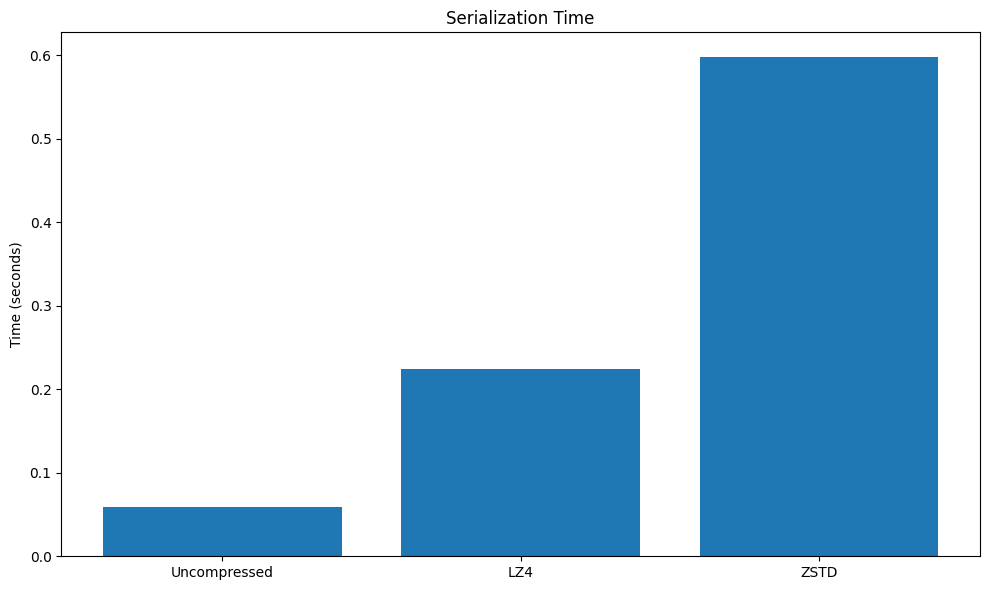

In [10]:
# ==============================================
# BLOCK 9 — Serialization Time Visualization
# ==============================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Codec"],
    results_df["Serialization_Time_s"]
)

plt.title("Serialization Time")
plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "serialization_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

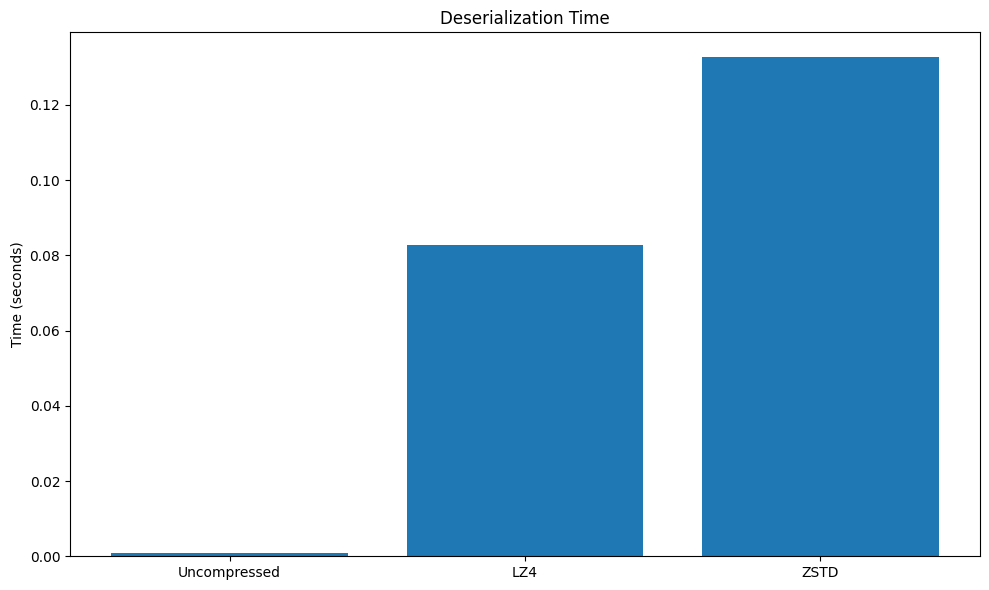

In [11]:
# ==============================================
# BLOCK 10 — Deserialization Time Visualization
# ==============================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Codec"],
    results_df["Deserialization_Time_s"]
)

plt.title("Deserialization Time")
plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "deserialization_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

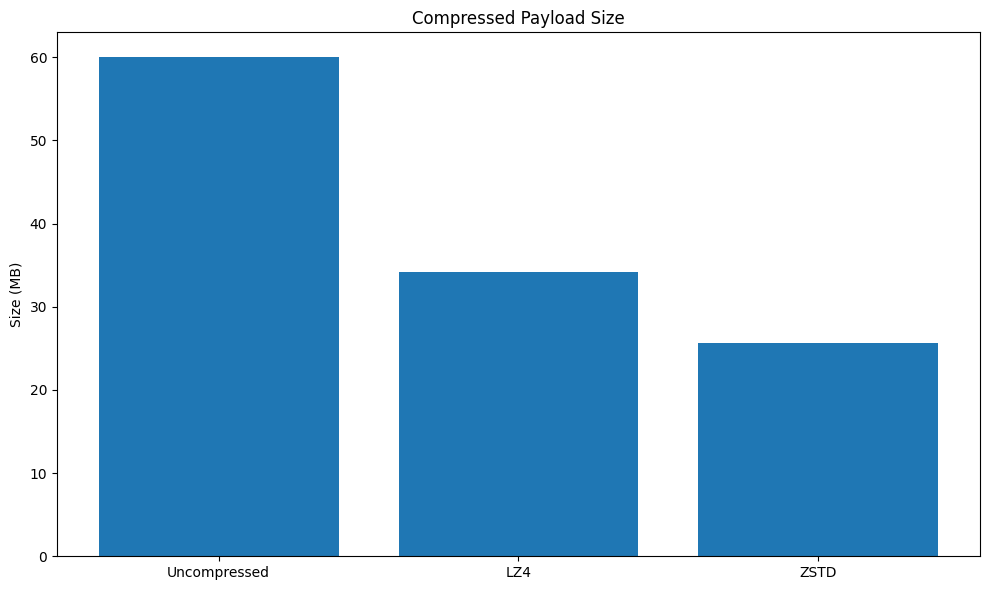

In [12]:
# ==============================================
# BLOCK 11 — Payload Size Visualization
# ==============================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Codec"],
    results_df["Payload_Size_MB"]
)

plt.title("Compressed Payload Size")
plt.ylabel("Size (MB)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "payload_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

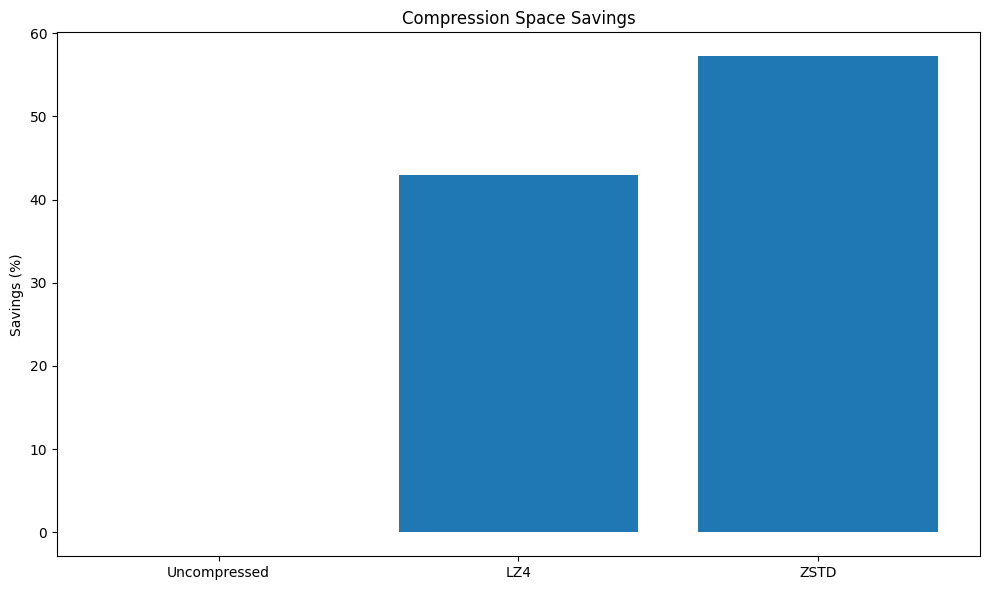

In [13]:
# ==============================================
# BLOCK 12 — Space Savings Visualization
# ==============================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Codec"],
    results_df["Space_Savings_Percent"]
)

plt.title("Compression Space Savings")
plt.ylabel("Savings (%)")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "space_savings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ==============================================
# BLOCK 13 — Save Results CSV
# ==============================================

results_csv_path = (
    TABLES_DIR /
    "compression_results.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print(
    f"\nResults saved to:\n"
    f"{results_csv_path}"
)


Results saved to:
/home/megh/arrow-ipc-analysis-linux/results/compression_effects/tables/compression_results.csv


In [15]:
# ==============================================
# BLOCK 14 — Save Summary Log
# ==============================================

summary_log_path = (
    LOGS_DIR /
    "summary.txt"
)

with open(summary_log_path, "w") as f:

    f.write("="*80 + "\n")
    f.write(
        "ARROW IPC COMPRESSION EFFECTS\n"
    )
    f.write("="*80 + "\n\n")

    f.write(results_df.to_string())

print(
    f"\nSummary log saved to:\n"
    f"{summary_log_path}"
)


Summary log saved to:
/home/megh/arrow-ipc-analysis-linux/results/compression_effects/logs/summary.txt


In [16]:
# ==============================================
# BLOCK 15 — Cleanup Message
# ==============================================

print("\nExperiment completed successfully.")


Experiment completed successfully.
